# Project 02 - Customer Behavior Analysis

This project analyzes customer behavior using the cleaned dataset from Project 01.

The main goal is to understand customer value, customer retention, city performance, discount usage, customer segments, and possible business opportunities.

In [2]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# loading the cleaned dataset from Project 01
df = pd.read_csv("cleaned_dataset_malihehabbasi-ml.csv")

df["signup_date"] = pd.to_datetime(df["signup_date"])

print("Shape:", df.shape)
df.head()

Shape: (60, 18)


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,gender_inferred
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,M
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,M
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,M
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,M
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,F


In [6]:
# checking the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     object        
 2   gender              60 non-null     object        
 3   age                 60 non-null     int64         
 4   city                60 non-null     object        
 5   province            60 non-null     object        
 6   signup_date         60 non-null     datetime64[ns]
 7   membership_tier     60 non-null     object        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     object        
 13  device              60 non-null     object        
 

In [8]:
# checking missing values before starting the analysis
print(df.isnull().sum())

customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
gender_inferred       0
dtype: int64


In [10]:
# checking basic statistics
df.describe()

,customer_id,age,signup_date,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,60.000000,60.000000,60,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1030.500000,43.700000,2023-02-03 14:00:00,17.666667,213.156500,3384.468667,198.600000,4.183333,2.983333
min,1001.000000,19.000000,2021-02-23 00:00:00,1.000000,27.630000,270.910000,3.000000,0.000000,1.000000
25%,1015.750000,31.750000,2021-12-06 12:00:00,11.000000,108.137500,1167.035000,134.250000,2.000000,2.000000
50%,1030.500000,45.000000,2022-08-15 00:00:00,17.000000,165.435000,2128.690000,203.000000,4.000000,3.000000
75%,1045.250000,58.000000,2024-06-14 12:00:00,24.500000,324.107500,4213.117500,273.750000,7.000000,4.000000
max,1060.000000,65.000000,2025-09-09 00:00:00,35.000000,449.810000,14354.340000,365.000000,8.000000,5.000000
std,17.464249,13.946994,NaN,9.890359,130.509923,3219.020544,97.843043,2.683861,1.431979


In [12]:
# creating a folder for charts
charts_path = Path("charts")
charts_path.mkdir(exist_ok=True)

## Question 1 - Overall Customer and Sales Status

The first step is to create a simple management summary of the current customer and sales situation.

In [15]:
# calculating the main business KPIs
total_customers = df["customer_id"].nunique()
total_purchases = df["purchase_count"].sum()
total_revenue = df["total_spending"].sum()
average_customer_spending = df["total_spending"].mean()
average_purchase_value = total_revenue / total_purchases
average_satisfaction = df["satisfaction_score"].mean()
return_rate = df["returned_items"].sum() / total_purchases * 100

print("Total customers:", total_customers)
print("Total purchases:", total_purchases)
print("Total revenue:", round(total_revenue,2))
print("Average spending per customer:", round(average_customer_spending,2))
print("Average purchase value:", round(average_purchase_value,2))
print("Average satisfaction:", round(average_satisfaction,2))
print("Return rate:", round(return_rate,2), "%")

Total customers: 60
Total purchases: 1060
Total revenue: 203068.12
Average spending per customer: 3384.47
Average purchase value: 191.57
Average satisfaction: 2.98
Return rate: 23.68 %


In [17]:
# creating a summary table for Question 1
q1_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Purchases",
        "Total Revenue",
        "Average Spending per Customer",
        "Average Purchase Value",
        "Average Satisfaction",
        "Return Rate"
    ],
    "Value": [
        total_customers,
        total_purchases,
        total_revenue,
        average_customer_spending,
        average_purchase_value,
        average_satisfaction,
        return_rate
    ]
})

q1_summary

,Metric,Value
0,Total Customers,60.000000
1,Total Purchases,1060.000000
2,Total Revenue,203068.120000
3,Average Spending per Customer,3384.468667
4,Average Purchase Value,191.573698
5,Average Satisfaction,2.983333
6,Return Rate,23.679245


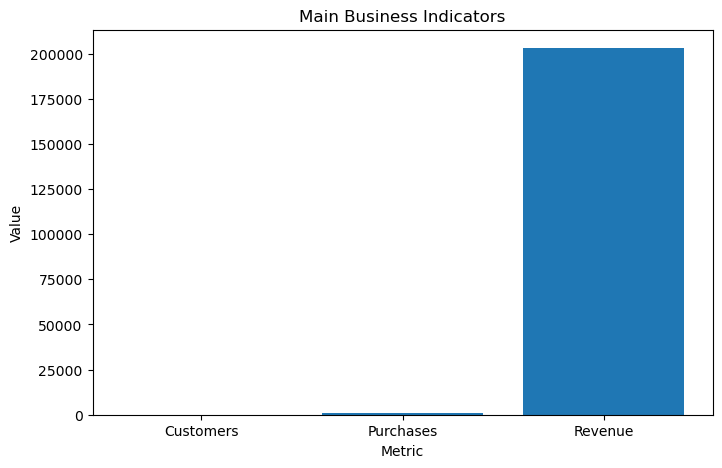

In [19]:
# visualizing the main customer KPIs
plt.figure(figsize=(8,5))
plt.bar(
    ["Customers","Purchases","Revenue"],
    [total_customers,total_purchases,total_revenue]
)
plt.title("Main Business Indicators")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.show()

### Question 1 - Interpretation

The store currently has 60 customers and 1,060 purchases, with total spending of 203,068.12.

The average spending per customer is 3,384.47 and the average purchase value is 191.57.

The average satisfaction score is 2.98 out of 5, which shows that customer satisfaction is not very strong and there is room for improvement.

The return rate is 23.68%, which is also relatively high and should be considered when planning sales and customer experience improvements.

## Question 2 - Which City Should Receive the Marketing Budget?

The company can invest in only one city. The decision should consider customer count, revenue, spending per customer, satisfaction, purchases, and return rate.

In [22]:
# calculating customer and sales statistics by city
city_stats = df.groupby(["province","city"]).agg(
    customers=("customer_id","nunique"),
    purchases=("purchase_count","sum"),
    revenue=("total_spending","sum"),
    avg_spending=("total_spending","mean"),
    satisfaction=("satisfaction_score","mean"),
    returns=("returned_items","sum")
).reset_index()

city_stats["return_rate"] = city_stats["returns"] / city_stats["purchases"] * 100

city_stats

,province,city,customers,purchases,revenue,avg_spending,satisfaction,returns,return_rate
0,Alborz,Karaj,7,112,26189.81,3741.401429,2.857143,34,30.357143
1,East Azerbaijan,Tabriz,12,189,36192.49,3016.040833,3.000000,55,29.100529
2,Fars,Shiraz,6,98,20715.92,3452.653333,2.000000,29,29.591837
3,Gilan,Rasht,5,82,15168.54,3033.708000,2.600000,22,26.829268
4,Isfahan,Isfahan,5,99,21975.32,4395.064000,4.400000,22,22.222222
5,Khorasan,Mashhad,11,249,43197.58,3927.052727,2.909091,29,11.646586
6,Khuzestan,Ahvaz,8,128,24467.17,3058.396250,3.500000,39,30.468750
7,Tehran,Tehran,6,103,15161.29,2526.881667,2.666667,21,20.388350


In [24]:
# removing very small groups from the main city comparison
city_rank = city_stats[city_stats["customers"] >= 3].copy()

print("Cities before filtering:", len(city_stats))
print("Cities used for ranking:", len(city_rank))

Cities before filtering: 8
Cities used for ranking: 8


In [26]:
# creating a simple score using the main city performance indicators
def normalize(series):
    if series.max() == series.min():
        return pd.Series(0.5,index=series.index)
    return (series - series.min()) / (series.max() - series.min())

city_rank["customer_score"] = normalize(city_rank["customers"])
city_rank["revenue_score"] = normalize(city_rank["revenue"])
city_rank["spending_score"] = normalize(city_rank["avg_spending"])
city_rank["satisfaction_score"] = normalize(city_rank["satisfaction"])
city_rank["purchase_score"] = normalize(city_rank["purchases"])
city_rank["return_score"] = 1 - normalize(city_rank["return_rate"])

city_rank["city_score"] = (
    city_rank["customer_score"] +
    city_rank["revenue_score"] +
    city_rank["spending_score"] +
    city_rank["satisfaction_score"] +
    city_rank["purchase_score"] +
    city_rank["return_score"]
) / 6

city_rank = city_rank.sort_values("city_score",ascending=False)

city_rank

,province,city,customers,purchases,revenue,avg_spending,satisfaction,returns,return_rate,customer_score,revenue_score,spending_score,satisfaction_score,purchase_score,return_score,city_score
5,Khorasan,Mashhad,11,249,43197.58,3927.052727,2.909091,29,11.646586,0.857143,1.000000,0.749483,0.378788,1.000000,1.000000,0.830902
1,East Azerbaijan,Tabriz,12,189,36192.49,3016.040833,3.000000,55,29.100529,1.000000,0.750142,0.261837,0.416667,0.640719,0.072692,0.523676
4,Isfahan,Isfahan,5,99,21975.32,4395.064000,4.400000,22,22.222222,0.000000,0.243043,1.000000,1.000000,0.101796,0.438129,0.463828
6,Khuzestan,Ahvaz,8,128,24467.17,3058.396250,3.500000,39,30.468750,0.428571,0.331923,0.284509,0.625000,0.275449,0.000000,0.324242
0,Alborz,Karaj,7,112,26189.81,3741.401429,2.857143,34,30.357143,0.285714,0.393366,0.650108,0.357143,0.179641,0.005930,0.311984
7,Tehran,Tehran,6,103,15161.29,2526.881667,2.666667,21,20.388350,0.142857,0.000000,0.000000,0.277778,0.125749,0.535560,0.180324
2,Fars,Shiraz,6,98,20715.92,3452.653333,2.000000,29,29.591837,0.142857,0.198123,0.495547,0.000000,0.095808,0.046589,0.163154
3,Gilan,Rasht,5,82,15168.54,3033.708000,2.600000,22,26.829268,0.000000,0.000259,0.271294,0.250000,0.000000,0.193361,0.119152


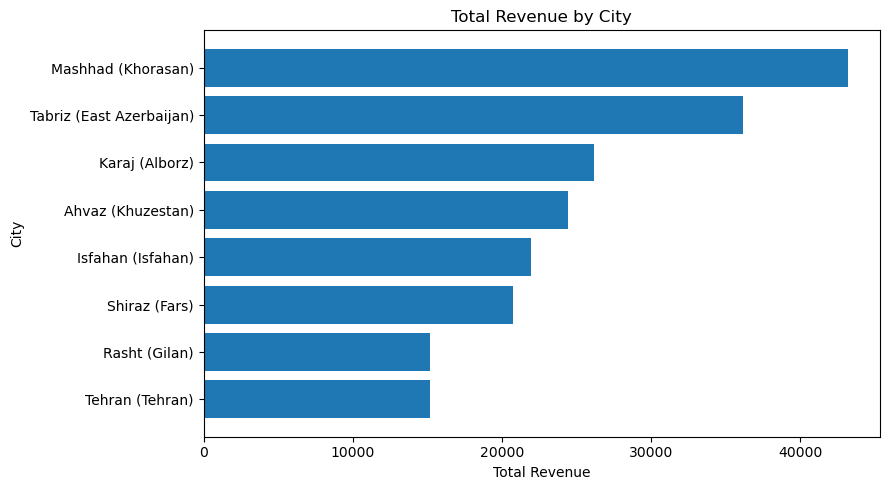

In [28]:
# comparing total revenue by city
plot_data = city_rank.sort_values("revenue")

plt.figure(figsize=(9,5))
plt.barh(
    plot_data["city"] + " (" + plot_data["province"] + ")",
    plot_data["revenue"]
)
plt.title("Total Revenue by City")
plt.xlabel("Total Revenue")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(charts_path / "q2_city_revenue.png",dpi=150)
plt.show()

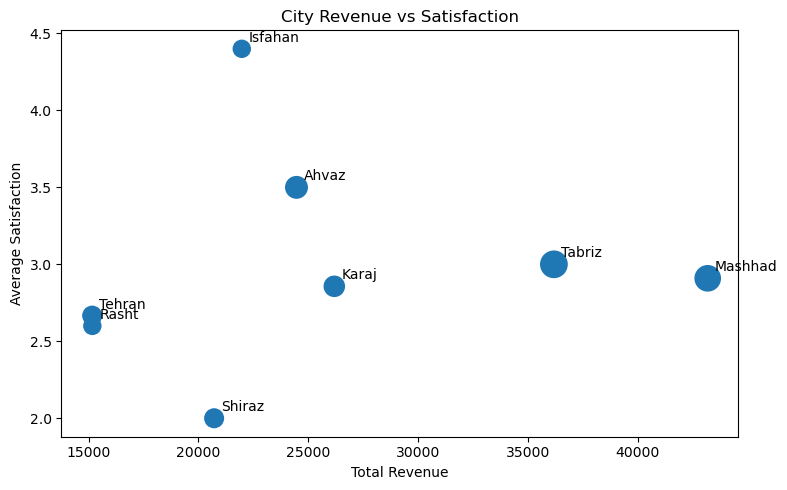

In [30]:
# comparing city revenue and satisfaction
plt.figure(figsize=(8,5))
plt.scatter(
    city_rank["revenue"],
    city_rank["satisfaction"],
    s=city_rank["customers"] * 30
)

for _,row in city_rank.iterrows():
    plt.annotate(
        row["city"],
        (row["revenue"],row["satisfaction"]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.title("City Revenue vs Satisfaction")
plt.xlabel("Total Revenue")
plt.ylabel("Average Satisfaction")
plt.tight_layout()
plt.savefig(charts_path / "q2_city_comparison.png",dpi=150)
plt.show()

In [32]:
# selecting the best city based on the overall score
best_city = city_rank.iloc[0]

print("Recommended city:",best_city["city"])
print("Province:",best_city["province"])
print("City score:",round(best_city["city_score"],3))
print("Customers:",best_city["customers"])
print("Revenue:",round(best_city["revenue"],2))
print("Average spending:",round(best_city["avg_spending"],2))
print("Satisfaction:",round(best_city["satisfaction"],2))
print("Return rate:",round(best_city["return_rate"],2),"%")

Recommended city: Mashhad
Province: Khorasan
City score: 0.831
Customers: 11
Revenue: 43197.58
Average spending: 3927.05
Satisfaction: 2.91
Return rate: 11.65 %


### Question 2 - Recommendation

Mashhad is the best city for the marketing budget based on the scoring method used in this analysis.

It has 11 customers, 249 purchases, and total revenue of 43,197.58. Its average customer spending is 3,927.05 and its return rate is only 11.65%, which is the lowest among the analyzed cities.

The main limitation is that the city score gives equal importance to all six indicators. A different weighting strategy could lead to a different result.

Based on the current data, Mashhad is the strongest overall choice for the first marketing campaign.

## Question 3 - Selecting the Top 10 Customers for a Loyalty Campaign

The goal is to select customers who have high business value and strong engagement.

The selection uses spending, purchase frequency, recency, and satisfaction.

In [35]:
# calculating customer loyalty scores
df["value_score"] = normalize(df["total_spending"])
df["frequency_score"] = normalize(df["purchase_count"])
df["recency_score"] = 1 - normalize(df["last_purchase_days"])
df["satisfaction_score_norm"] = normalize(df["satisfaction_score"])

df["loyalty_score"] = (
    0.40 * df["value_score"] +
    0.30 * df["frequency_score"] +
    0.20 * df["recency_score"] +
    0.10 * df["satisfaction_score_norm"]
)

In [37]:
# selecting the top 10 customers for the loyalty campaign
top10 = df.nlargest(10,"loyalty_score").copy()

top10 = top10[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score",
        "loyalty_score"
    ]
]

top10

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score
56,1057,Maryam,Ahvaz,Bronze,31,13532.74,82,4,0.872724
43,1044,Mina,Shiraz,Gold,33,14354.34,165,2,0.817850
8,1009,Kimia,Karaj,Silver,34,11615.42,232,2,0.711866
58,1059,Ali,Isfahan,Gold,31,8898.55,224,5,0.687650
11,1012,Arash,Mashhad,Gold,27,11731.50,224,2,0.657818
3,1004,Sina,Mashhad,Gold,23,6121.45,40,4,0.614844
32,1033,Neda,Tabriz,VIP,24,5521.20,112,5,0.591840
13,1014,Reza,Tabriz,VIP,31,3353.89,97,4,0.575336
22,1023,Ali,Mashhad,Bronze,31,3851.44,170,4,0.549136
16,1017,Parsa,Ahvaz,VIP,30,3239.40,135,4,0.542266


In [39]:
# creating a reason for each loyalty selection
spending_q75 = df["total_spending"].quantile(0.75)
purchase_q75 = df["purchase_count"].quantile(0.75)
recent_median = df["last_purchase_days"].median()

def selection_reason(row):
    reasons = []

    if row["total_spending"] >= spending_q75:
        reasons.append("high spending")

    if row["purchase_count"] >= purchase_q75:
        reasons.append("frequent purchases")

    if row["last_purchase_days"] <= recent_median:
        reasons.append("recent activity")

    if row["satisfaction_score"] >= df["satisfaction_score"].median():
        reasons.append("good satisfaction")

    return ", ".join(reasons)

top10["Reason for Selection"] = top10.apply(selection_reason,axis=1)

top10

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score,Reason for Selection
56,1057,Maryam,Ahvaz,Bronze,31,13532.74,82,4,0.872724,"high spending, frequent purchases, recent acti..."
43,1044,Mina,Shiraz,Gold,33,14354.34,165,2,0.817850,"high spending, frequent purchases, recent acti..."
8,1009,Kimia,Karaj,Silver,34,11615.42,232,2,0.711866,"high spending, frequent purchases"
58,1059,Ali,Isfahan,Gold,31,8898.55,224,5,0.687650,"high spending, frequent purchases, good satisf..."
11,1012,Arash,Mashhad,Gold,27,11731.50,224,2,0.657818,"high spending, frequent purchases"
3,1004,Sina,Mashhad,Gold,23,6121.45,40,4,0.614844,"high spending, recent activity, good satisfaction"
32,1033,Neda,Tabriz,VIP,24,5521.20,112,5,0.591840,"high spending, recent activity, good satisfaction"
13,1014,Reza,Tabriz,VIP,31,3353.89,97,4,0.575336,"frequent purchases, recent activity, good sati..."
22,1023,Ali,Mashhad,Bronze,31,3851.44,170,4,0.549136,"frequent purchases, recent activity, good sati..."
16,1017,Parsa,Ahvaz,VIP,30,3239.40,135,4,0.542266,"frequent purchases, recent activity, good sati..."


In [41]:
# creating the final loyalty campaign table
top10_final = top10[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score",
        "Reason for Selection"
    ]
]

top10_final

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,Reason for Selection
56,1057,Maryam,Ahvaz,Bronze,31,13532.74,82,4,"high spending, frequent purchases, recent acti..."
43,1044,Mina,Shiraz,Gold,33,14354.34,165,2,"high spending, frequent purchases, recent acti..."
8,1009,Kimia,Karaj,Silver,34,11615.42,232,2,"high spending, frequent purchases"
58,1059,Ali,Isfahan,Gold,31,8898.55,224,5,"high spending, frequent purchases, good satisf..."
11,1012,Arash,Mashhad,Gold,27,11731.50,224,2,"high spending, frequent purchases"
3,1004,Sina,Mashhad,Gold,23,6121.45,40,4,"high spending, recent activity, good satisfaction"
32,1033,Neda,Tabriz,VIP,24,5521.20,112,5,"high spending, recent activity, good satisfaction"
13,1014,Reza,Tabriz,VIP,31,3353.89,97,4,"frequent purchases, recent activity, good sati..."
22,1023,Ali,Mashhad,Bronze,31,3851.44,170,4,"frequent purchases, recent activity, good sati..."
16,1017,Parsa,Ahvaz,VIP,30,3239.40,135,4,"frequent purchases, recent activity, good sati..."


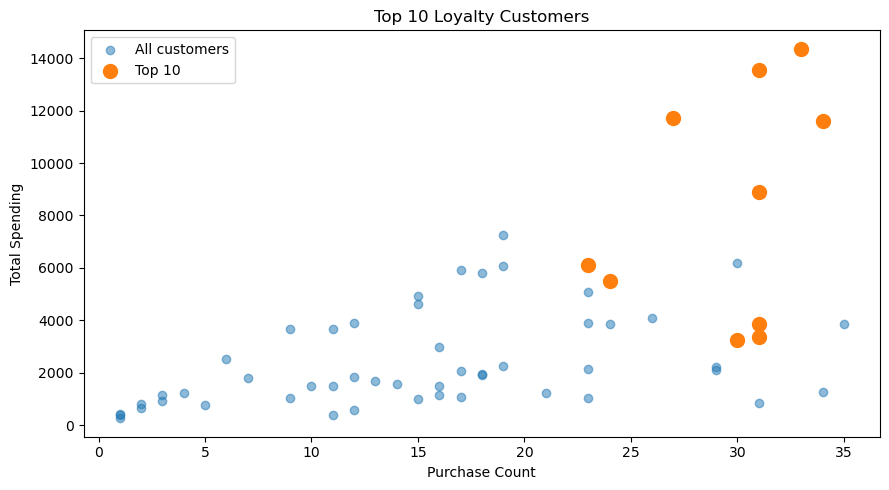

In [43]:
# visualizing the selected loyalty customers
plt.figure(figsize=(9,5))
plt.scatter(
    df["purchase_count"],
    df["total_spending"],
    alpha=0.5,
    label="All customers"
)

plt.scatter(
    top10["purchase_count"],
    top10["total_spending"],
    s=100,
    label="Top 10"
)

plt.title("Top 10 Loyalty Customers")
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.legend()
plt.tight_layout()
plt.savefig(charts_path / "q3_top10_loyalty.png",dpi=150)
plt.show()

### Question 3 - Interpretation

The loyalty score combines spending, purchase frequency, recent activity, and satisfaction.

The selected customers are not based only on the highest spending. For example, some customers with lower spending were selected because they purchase frequently and have relatively recent activity.

This makes the list more useful for a loyalty campaign because the goal is to reward customers who show both value and engagement.

## Question 4 - Customers at Risk of Churn

A customer is considered at risk when they have high past spending but have not purchased recently.

For this analysis:
- High value = top 25% of total spending
- Long inactivity = top 25% of last purchase days

In [46]:
# identifying customers at risk of churn
spending_threshold = df["total_spending"].quantile(0.75)
inactivity_threshold = df["last_purchase_days"].quantile(0.75)

df["at_risk"] = (
    (df["total_spending"] >= spending_threshold) &
    (df["last_purchase_days"] >= inactivity_threshold)
)

at_risk = df[df["at_risk"]].copy()

print("Spending threshold:",round(spending_threshold,2))
print("Inactivity threshold:",round(inactivity_threshold,2))
print("At-risk customers:",len(at_risk))

at_risk[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
]

Spending threshold: 4213.12
Inactivity threshold: 273.75
At-risk customers: 3


,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
9,1010,Arash,Karaj,Silver,19,7241.47,276,1
34,1035,Arash,Tabriz,Bronze,17,5918.21,365,3
52,1053,Sina,Tehran,Gold,18,5805.54,320,1


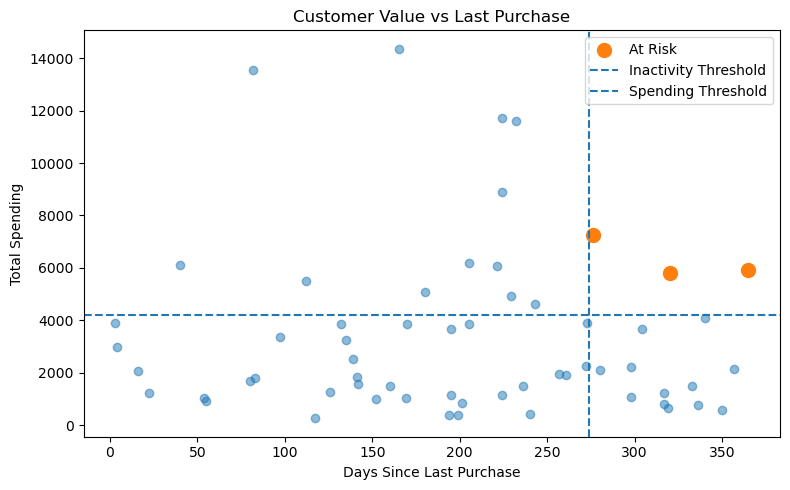

In [48]:
# visualizing high value and inactive customers
plt.figure(figsize=(8,5))

plt.scatter(
    df["last_purchase_days"],
    df["total_spending"],
    alpha=0.5
)

plt.scatter(
    at_risk["last_purchase_days"],
    at_risk["total_spending"],
    s=100,
    label="At Risk"
)

plt.axvline(
    inactivity_threshold,
    linestyle="--",
    label="Inactivity Threshold"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    label="Spending Threshold"
)

plt.title("Customer Value vs Last Purchase")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.tight_layout()
plt.savefig(charts_path / "q4_at_risk_customers.png",dpi=150)
plt.show()

### Question 4 - Interpretation

Three customers were identified as being at risk of churn.

The definition used was a customer whose total spending is in the top 25% and whose last purchase is also in the top 25% of inactivity.

The three customers are 1010, 1035, and 1053.

These customers are important because they have already generated relatively high spending but have not purchased for a long time.

A targeted win-back campaign would be more appropriate than sending the same promotion to all customers.

## Question 5 - Do Discounts Increase Customer Spending?

Customers who used discounts will be compared with customers who did not use discounts.

The comparison is descriptive and does not prove that discounts caused the observed differences.

In [51]:
# comparing customers who used discounts with customers who did not
discount_stats = df.groupby("discount_used").agg(
    customers=("customer_id","nunique"),
    average_spending=("total_spending","mean"),
    average_purchase_count=("purchase_count","mean"),
    average_satisfaction=("satisfaction_score","mean"),
    returned_items=("returned_items","sum"),
    purchases=("purchase_count","sum")
).reset_index()

discount_stats["return_rate"] = (
    discount_stats["returned_items"] /
    discount_stats["purchases"] * 100
)

discount_stats

,discount_used,customers,average_spending,average_purchase_count,average_satisfaction,returned_items,purchases,return_rate
0,No,34,3768.576176,17.794118,2.764706,145,605,23.966942
1,Yes,26,2882.174231,17.500000,3.269231,106,455,23.296703


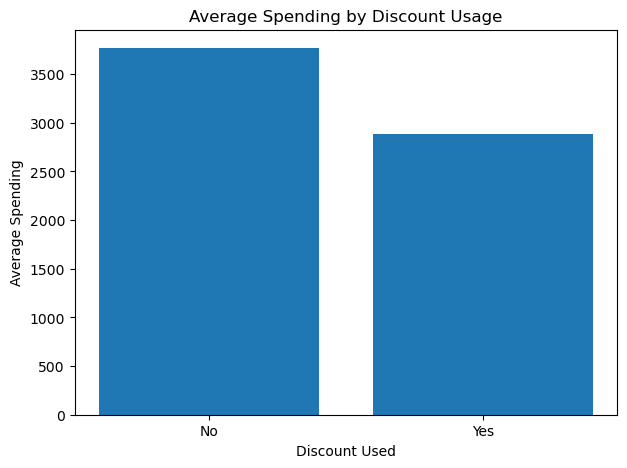

In [53]:
# visualizing average spending by discount usage
plt.figure(figsize=(7,5))
plt.bar(
    discount_stats["discount_used"],
    discount_stats["average_spending"]
)
plt.title("Average Spending by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Spending")
plt.show()

### Question 5 - Interpretation

Customers who did not use discounts had higher average spending than customers who used discounts.

Average spending was 3,768.58 for the non-discount group and 2,882.17 for the discount group.

The average purchase count was also slightly higher for the non-discount group.

However, this does not mean that discounts reduce sales. The two groups may have different characteristics from the beginning.

Therefore, based on this dataset, we cannot conclude that discounts cause higher or lower sales. A controlled experiment would be needed to measure the real effect of discounts.

## Question 6 - Customer Segmentation

Customers will be divided into simple rule-based groups.

The groups are based on spending, purchase frequency, recency, and customer satisfaction.

In [56]:
# creating thresholds for customer segmentation
spending_median = df["total_spending"].median()
purchase_median = df["purchase_count"].median()
inactive_median = df["last_purchase_days"].median()
satisfaction_median = df["satisfaction_score"].median()

spending_q75 = df["total_spending"].quantile(0.75)
purchase_q75 = df["purchase_count"].quantile(0.75)
inactive_q75 = df["last_purchase_days"].quantile(0.75)

In [58]:
# assigning customers to rule-based segments
conditions = [
    (
        (df["total_spending"] >= spending_q75) &
        (df["purchase_count"] >= purchase_q75) &
        (df["last_purchase_days"] <= inactive_median)
    ),
    (
        (df["total_spending"] >= spending_median) &
        (df["purchase_count"] >= purchase_median) &
        (df["last_purchase_days"] <= inactive_median)
    ),
    (
        (df["total_spending"] >= spending_q75) &
        (df["last_purchase_days"] >= inactive_q75)
    ),
    (
        (df["total_spending"] < spending_median) &
        (df["last_purchase_days"] >= inactive_median)
    )
]

choices = [
    "Champions",
    "Loyal Customers",
    "At Risk",
    "Needs Attention"
]

df["segment"] = np.select(
    conditions,
    choices,
    default="Potential Growth"
)

df["segment"].value_counts()

segment
Potential Growth    35
Needs Attention     13
Loyal Customers      7
At Risk              3
Champions            2
Name: count, dtype: int64

In [60]:
# summarizing each customer segment
segment_summary = df.groupby("segment").agg(
    customers=("customer_id","nunique"),
    revenue=("total_spending","sum"),
    avg_spending=("total_spending","mean"),
    avg_purchases=("purchase_count","mean"),
    avg_satisfaction=("satisfaction_score","mean"),
    avg_last_purchase_days=("last_purchase_days","mean")
).reset_index()

segment_summary.sort_values("revenue",ascending=False)

,segment,customers,revenue,avg_spending,avg_purchases,avg_satisfaction,avg_last_purchase_days
4,Potential Growth,35,109446.03,3127.029429,17.457143,3.171429,173.542857
2,Loyal Customers,7,31039.31,4434.187143,26.571429,3.571429,123.714286
1,Champions,2,27887.08,13943.540000,32.000000,3.000000,123.500000
0,At Risk,3,18965.22,6321.740000,18.000000,1.666667,320.333333
3,Needs Attention,13,15730.48,1210.036923,11.153846,2.461538,289.846154


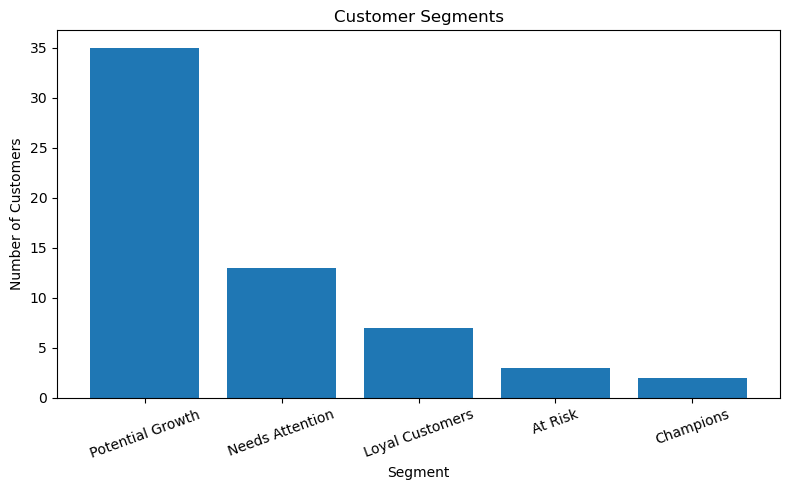

In [62]:
# visualizing customer segment sizes
segment_counts = df["segment"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(segment_counts.index,segment_counts.values)
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(charts_path / "q6_customer_segments.png",dpi=150)
plt.show()

### Question 6 - Interpretation

The largest customer group is Potential Growth, with 35 customers.

Champions contains only 2 customers, but their average spending is very high at 13,943.54.

The At Risk group contains 3 customers. Their average spending is 6,321.74, but their average inactivity is 320.33 days and their average satisfaction is only 1.67.

This means that the company should not treat all customers in the same way.

Champions should be protected, Loyal Customers should be developed, At Risk customers should be reactivated, and the Potential Growth group should be encouraged to increase purchase frequency and spending.

## Question 7 - Revenue Concentration and Pareto Analysis

The goal is to check whether a small number of customers generate a large share of total revenue.

In [65]:
# calculating revenue concentration across customers
pareto = df[["customer_id","first_name","total_spending"]].copy()
pareto = pareto.sort_values("total_spending",ascending=False)

pareto["cumulative_revenue"] = pareto["total_spending"].cumsum()
pareto["cumulative_percent"] = (
    pareto["cumulative_revenue"] /
    pareto["total_spending"].sum() * 100
)

top20_count = int(np.ceil(len(pareto) * 0.20))
top20_revenue_share = (
    pareto.head(top20_count)["total_spending"].sum() /
    pareto["total_spending"].sum() * 100
)

print("Top 20% customer count:",top20_count)
print("Top 20% revenue share:",round(top20_revenue_share,2),"%")

Top 20% customer count: 12
Top 20% revenue share: 50.73 %


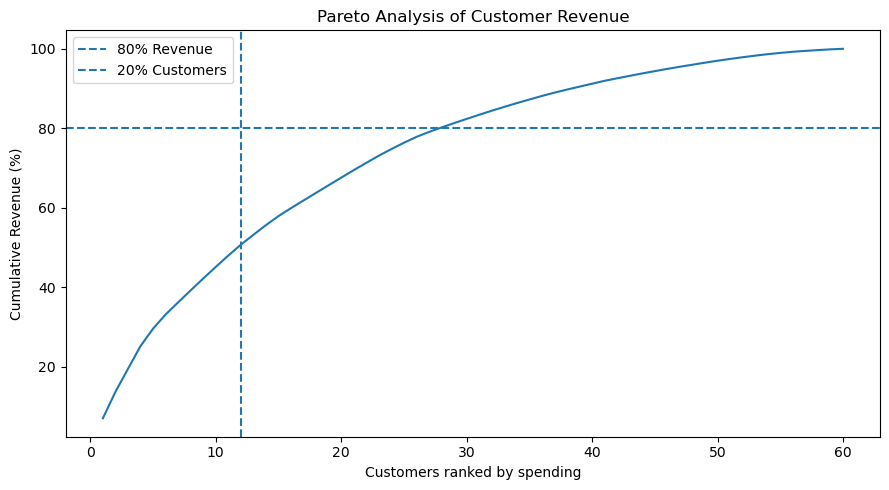

In [67]:
# visualizing cumulative revenue contribution
plt.figure(figsize=(9,5))

plt.plot(
    range(1,len(pareto)+1),
    pareto["cumulative_percent"]
)

plt.axhline(80,linestyle="--",label="80% Revenue")
plt.axvline(top20_count,linestyle="--",label="20% Customers")

plt.title("Pareto Analysis of Customer Revenue")
plt.xlabel("Customers ranked by spending")
plt.ylabel("Cumulative Revenue (%)")
plt.legend()
plt.tight_layout()
plt.savefig(charts_path / "q7_pareto_analysis.png",dpi=150)
plt.show()

### Question 7 - Interpretation

The top 20% of customers are 12 customers in this dataset.

They generate 50.73% of the total revenue.

This means that revenue is concentrated among the higher-value customers, but the dataset does not follow the classic 80/20 pattern.

The company still needs to protect high-value customers, but it is not completely dependent on a very small group.

## Question 8 - Three Charts for the CEO

Only three charts will be selected for the five-minute management presentation.

The charts should show the most important opportunity, risk, and customer structure.

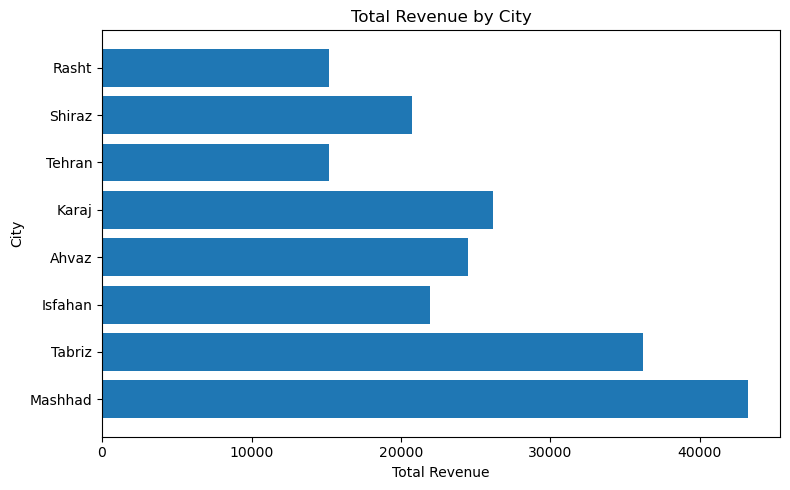

In [70]:
# creating the first executive chart
plt.figure(figsize=(8,5))

plt.barh(
    city_rank["city"],
    city_rank["revenue"]
)

plt.title("Total Revenue by City")
plt.xlabel("Total Revenue")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(charts_path / "executive_city_revenue.png",dpi=150)
plt.show()

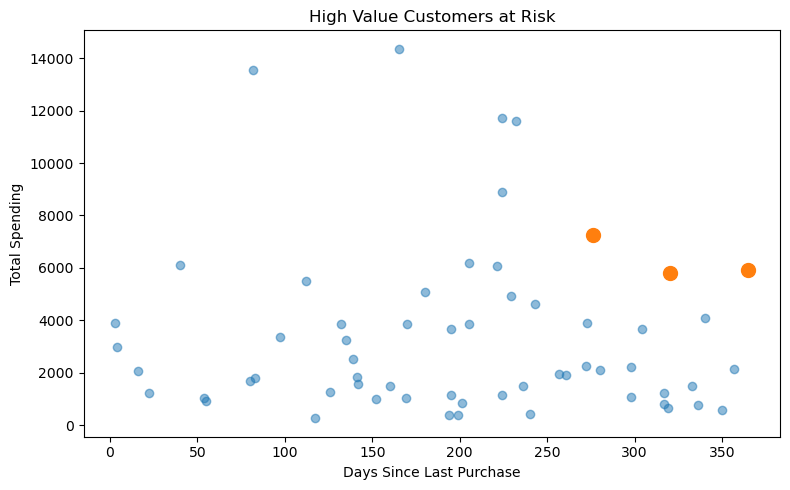

In [74]:
# creating the second executive chart
plt.figure(figsize=(8,5))

plt.scatter(
    df["last_purchase_days"],
    df["total_spending"],
    alpha=0.5
)

plt.scatter(
    at_risk["last_purchase_days"],
    at_risk["total_spending"],
    s=100
)

plt.title("High Value Customers at Risk")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.savefig(charts_path / "executive_at_risk.png",dpi=150)
plt.show()

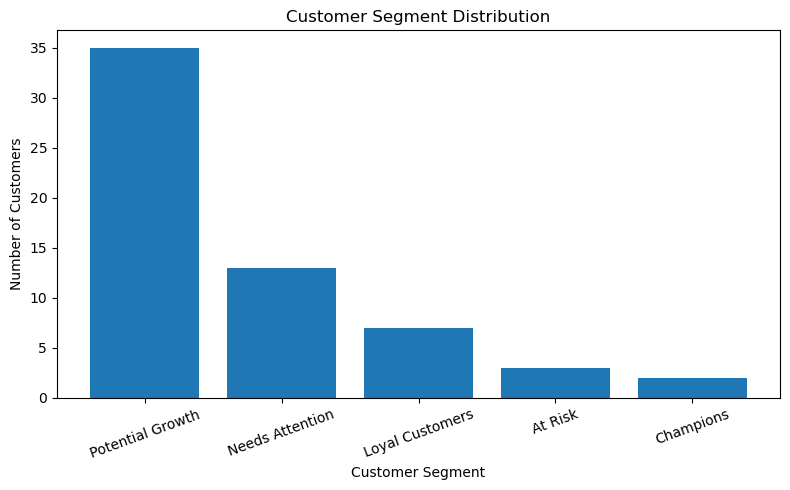

In [78]:
# creating the third executive chart
plt.figure(figsize=(8,5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(charts_path / "executive_segments.png",dpi=150)
plt.show()

### Question 8 - Executive View

For a short management presentation, the three most useful charts are:

1. Revenue by City - shows where the marketing budget could have the strongest impact.
2. High-Value Customers at Risk - shows which valuable customers need retention attention.
3. Customer Segment Distribution - shows the size of the main customer groups and where the largest opportunities are.

## Question 9 - Three Data-Driven Recommendations

Each recommendation should be based directly on an observation from the analysis.

Every recommendation will include:

- Evidence
- Action
- KPI

In [81]:
# preparing the main evidence for business recommendations
discount_used = discount_stats[
    discount_stats["discount_used"].astype(str).str.lower() == "yes"
].iloc[0]

discount_not_used = discount_stats[
    discount_stats["discount_used"].astype(str).str.lower() == "no"
].iloc[0]

print("Best city:",best_city["city"])
print("Best city revenue:",round(best_city["revenue"],2))

print("\nAt-risk customers:",len(at_risk))

print("\nTop 20% revenue share:",round(top20_revenue_share,2),"%")

print("\nDiscount users average spending:",round(discount_used["average_spending"],2))
print("Non-discount users average spending:",round(discount_not_used["average_spending"],2))

print("\nLargest customer segment:")
print(segment_summary.sort_values("customers",ascending=False).iloc[0]["segment"])

Best city: Mashhad
Best city revenue: 43197.58

At-risk customers: 3

Top 20% revenue share: 50.73 %

Discount users average spending: 2882.17
Non-discount users average spending: 3768.58

Largest customer segment:
Potential Growth


### Question 9 - Recommendation Summary

The analysis leads to three main actions:

1. Test the first marketing campaign in Mashhad because it has the highest overall city score.
2. Run a targeted win-back campaign for the three high-value inactive customers.
3. Avoid giving discounts to all customers and instead test targeted discounts with clear KPIs.

## Question 10 - Dataset Limitations

In [84]:
# checking the final analysis data
print("Customers:",df["customer_id"].nunique())
print("Revenue:",round(df["total_spending"].sum(),2))
print("Purchases:",df["purchase_count"].sum())
print("Average satisfaction:",round(df["satisfaction_score"].mean(),2))
print("At-risk customers:",len(at_risk))
print("Top city:",best_city["city"])
print("Top 20% revenue share:",round(top20_revenue_share,2),"%")
print("Customer segments:",df["segment"].nunique())

Customers: 60
Revenue: 203068.12
Purchases: 1060
Average satisfaction: 2.98
At-risk customers: 3
Top city: Mashhad
Top 20% revenue share: 50.73 %
Customer segments: 5


## Question 10 - Dataset Limitations

There are several limitations in this dataset.

1. The dataset is small, with only 60 customers, so the results may not represent a larger customer population.

2. The data is customer-level rather than transaction-level, so detailed order and product analysis is not possible.

3. Profit information is not available, so high spending cannot automatically be considered high profitability.

4. Shipping cost is not available.

5. Exact order dates are not available, so detailed monthly or weekly sales trends cannot be studied.

6. Product categories are not available, so product-level sales and return analysis cannot be performed.

7. Customer acquisition source is not available, so different marketing channels cannot be compared.

8. Advertising cost is not available, so marketing ROI cannot be calculated.

Useful additional columns would include profit per order, shipping cost, product category, exact order date, acquisition source, advertising cost, and membership date.

In [86]:
# saving the analysis-ready customer dataset
df.to_csv("cleaned_customers.csv",index=False)

print("Analysis dataset saved successfully.")

Analysis dataset saved successfully.
